# Isolation Forest SST El Niño — Research Supplement

**Title:** Anomaly Detection Analysis of Sea Surface Temperature as an El Niño Indicator Using the Isolation Forest Algorithm  
**Positioning:** Formal supplementary notebook accompanying the IEEE-style manuscript.  
**Goal:** Present a reproducible, literature-aware, and analytically grounded workflow for SST anomaly detection using the TAO buoy dataset.

## Analytical roadmap
1. Frame the climate and methodological problem using literature-backed motivation.
2. Clean the TAO-derived SST observations and assess data quality.
3. Build a location-aware monthly SST anomaly proxy for comparative benchmarking.
4. Compare `IsolationForest`, `OneClassSVM`, and `LocalOutlierFactor` on SST-only and multivariate feature sets.
5. Extend the analysis through diagnostics, ablation, robustness checks, and event-level interpretation.
6. Conclude with findings, limitations, and reproducibility artifacts.


## 1. Research motivation and domain framing

ENSO is one of the most important climate variability mechanisms in the tropical Pacific because it affects rainfall, drought risk, agricultural productivity, and economic stability. This framing is consistent with the reference materials in `resources/papers-references`, especially the economic perspective of `Callahan-and-Mankin-Science-2023.pdf` and the domain-specific motivation recorded in `[base papers] Analisis Deteksi Anomali Suhu Permukaan Laut Sebagai Indikator El Niño Menggunakan Algoritma Isolation Forest.md`.

For this reason, SST anomalies are an informative signal for early climate monitoring. However, the references also suggest that SST variability is nonlinear and cannot always be summarized adequately by a single fixed threshold. This motivates a complementary anomaly-detection perspective in addition to classical ENSO indicators.


## 2. Literature-informed analytical stance

This notebook uses explicit insights from the project reference folder:

- `Non-linear_modes_of_global_sea_surface_temperature.pdf` motivates the view that SST variability contains nonlinear structure.
- `Isolation_Forest.pdf` motivates the use of Isolation Forest as a scalable unsupervised anomaly detector.
- `Extended_Isolation_Forest_with_Randomly_Oriented_H.pdf` motivates robustness discussion around iForest-style partitioning.
- `noaa_56313_DS1.pdf` and the broader ENSO literature motivate caution when using proxy labels instead of official operational event labels.

The notebook therefore treats `IsolationForest` as the focal method, but evaluates it comparatively against `OneClassSVM` and `LocalOutlierFactor` rather than assuming it is automatically superior.


## 3. Reproducibility setup

The workflow below is self-contained. All data are loaded from this portfolio repository and all exported tables are written to `results/` so that the notebook can function as a reproducible supplementary research artifact.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

def find_portfolio_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "elnino.csv").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate portfolio root containing data/elnino.csv")

PORTFOLIO_ROOT = find_portfolio_root()
DATA_PATH = PORTFOLIO_ROOT / "data" / "elnino.csv"
OUTPUT_DIR = PORTFOLIO_ROOT / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_CONTAMINATION = 0.10
RANDOM_STATE = 42

print("Portfolio structure detected.")
print("Dataset path: data/elnino.csv")
print("Output directory: results/")


Portfolio structure detected.
Dataset path: data/elnino.csv
Output directory: results/


## 4. Raw dataset inspection

Before any modeling, the notebook verifies the structure of the source file. This is important because climate datasets often contain formatting artifacts, irregular missing markers, or mixed-type columns that can distort anomaly analysis if left untreated.


In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [3]:
def prepare_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [column.strip() for column in df.columns]

    numeric_columns = [
        "Observation",
        "Year",
        "Month",
        "Day",
        "Latitude",
        "Longitude",
        "Zonal Winds",
        "Meridional Winds",
        "Humidity",
        "Air Temp",
        "Sea Surface Temp",
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column].replace(".", np.nan), errors="coerce")

    df["FullYear"] = np.where(df["Year"] >= 50, 1900 + df["Year"], 2000 + df["Year"])
    df["Date"] = pd.to_datetime(
        {"year": df["FullYear"], "month": df["Month"], "day": df["Day"]},
        errors="coerce",
    )
    df["MonthStart"] = df["Date"].values.astype("datetime64[M]")
    df["CalendarMonth"] = df["MonthStart"].dt.month
    return df

df = prepare_dataset(raw_df)
df.head()


,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp,FullYear,MonthStart,CalendarMonth
0,1,80,3,7,1980-03-07,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,1980,1980-03-01,3
1,2,80,3,8,1980-03-08,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,1980,1980-03-01,3
2,3,80,3,9,1980-03-09,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,1980,1980-03-01,3
3,4,80,3,10,1980-03-10,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,1980,1980-03-01,3
4,5,80,3,11,1980-03-11,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,1980,1980-03-01,3


## 5. Data quality and preprocessing validity

The preprocessing stage should do more than “make the code run.” It should demonstrate that the resulting monthly benchmark is built on interpretable, temporally valid, and geographically plausible observations. The following cells quantify missingness, coverage, and temporal range.


In [4]:
quality_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    }
).sort_values("missing_pct", ascending=False)

dataset_summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "date_min": df["Date"].min(),
        "date_max": df["Date"].max(),
        "duplicate_rows": int(df.duplicated().sum()),
        "unique_latitudes": df["Latitude"].nunique(),
        "unique_longitudes": df["Longitude"].nunique(),
        "valid_sst_rows": int(df["Sea Surface Temp"].notna().sum()),
    },
    name="value",
)
display(dataset_summary.to_frame())
display(quality_summary)


,value
rows,178080
columns,15
date_min,1980-03-07 00:00:00
date_max,1998-06-23 00:00:00
duplicate_rows,0
unique_latitudes,682
unique_longitudes,1657
valid_sst_rows,161073


,dtype,missing_values,missing_pct
Humidity,float64,65761,36.93
Zonal Winds,float64,25163,14.13
Meridional Winds,float64,25162,14.13
Air Temp,float64,18237,10.24
Sea Surface Temp,float64,17007,9.55
Observation,int64,0,0.00
Year,int64,0,0.00
Month,int64,0,0.00
Day,int64,0,0.00
Date,datetime64[ns],0,0.00


In [5]:
missing_output_path = OUTPUT_DIR / "data_missingness_summary.csv"
quality_summary.to_csv(missing_output_path)
print("Saved data quality summary to results/data_missingness_summary.csv")


Saved data quality summary to results/data_missingness_summary.csv


## 6. Exploratory data analysis

A research-grade notebook should show whether the modeling problem is supported by the data structure. The EDA below focuses on temporal density, variable distributions, spatial coverage, and broad seasonal organization. These diagnostics matter because anomaly detectors can be sensitive to sampling imbalance and shifts in temporal coverage.


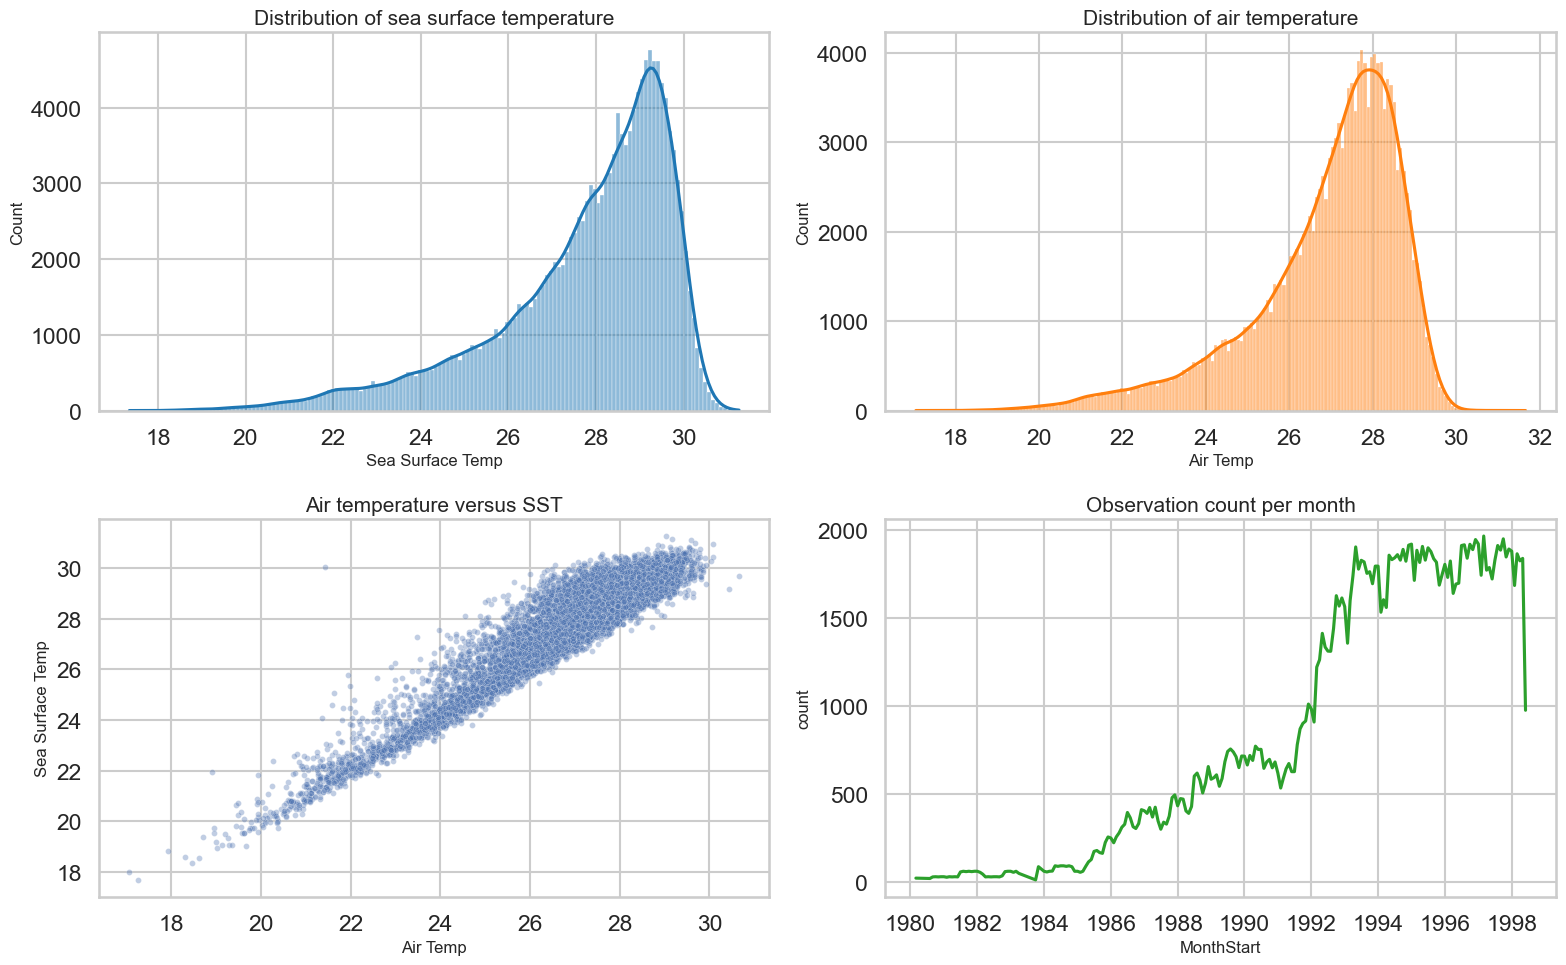

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["Sea Surface Temp"], kde=True, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribution of sea surface temperature")

sns.histplot(df["Air Temp"], kde=True, ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("Distribution of air temperature")

sample_scatter = df[["Air Temp", "Sea Surface Temp"]].dropna().sample(
    n=min(12000, df[["Air Temp", "Sea Surface Temp"]].dropna().shape[0]),
    random_state=RANDOM_STATE,
)
sns.scatterplot(data=sample_scatter, x="Air Temp", y="Sea Surface Temp", s=18, alpha=0.35, ax=axes[1, 0])
axes[1, 0].set_title("Air temperature versus SST")

monthly_counts = df.groupby("MonthStart")["Observation"].count().reset_index(name="count")
sns.lineplot(data=monthly_counts, x="MonthStart", y="count", ax=axes[1, 1], color="tab:green")
axes[1, 1].set_title("Observation count per month")

plt.tight_layout()
plt.show()


In [7]:
temporal_density = (
    df.groupby("MonthStart")
    .agg(observations=("Observation", "count"), sst_available=("Sea Surface Temp", lambda x: x.notna().sum()))
    .reset_index()
)

seasonal_profile = (
    df.groupby("CalendarMonth")
    .agg(
        sst_mean=("Sea Surface Temp", "mean"),
        air_temp_mean=("Air Temp", "mean"),
        obs_count=("Observation", "count"),
    )
    .reset_index()
)
display(temporal_density.head())
display(seasonal_profile)


,MonthStart,observations,sst_available
0,1980-03-01,23,15
1,1980-08-01,21,21
2,1980-09-01,30,30
3,1980-10-01,31,31
4,1980-11-01,30,30


,CalendarMonth,sst_mean,air_temp_mean,obs_count
0,1,27.438666,26.725270,15169
1,2,27.705621,27.003735,13818
2,3,28.039632,27.299287,15329
3,4,28.331711,27.486717,14822
4,5,28.295848,27.461312,15842
5,6,28.013526,27.140827,14630
6,7,27.666553,26.763800,14410
7,8,27.367351,26.489212,14601
8,9,27.393043,26.506136,14489
9,10,27.511695,26.607918,14871


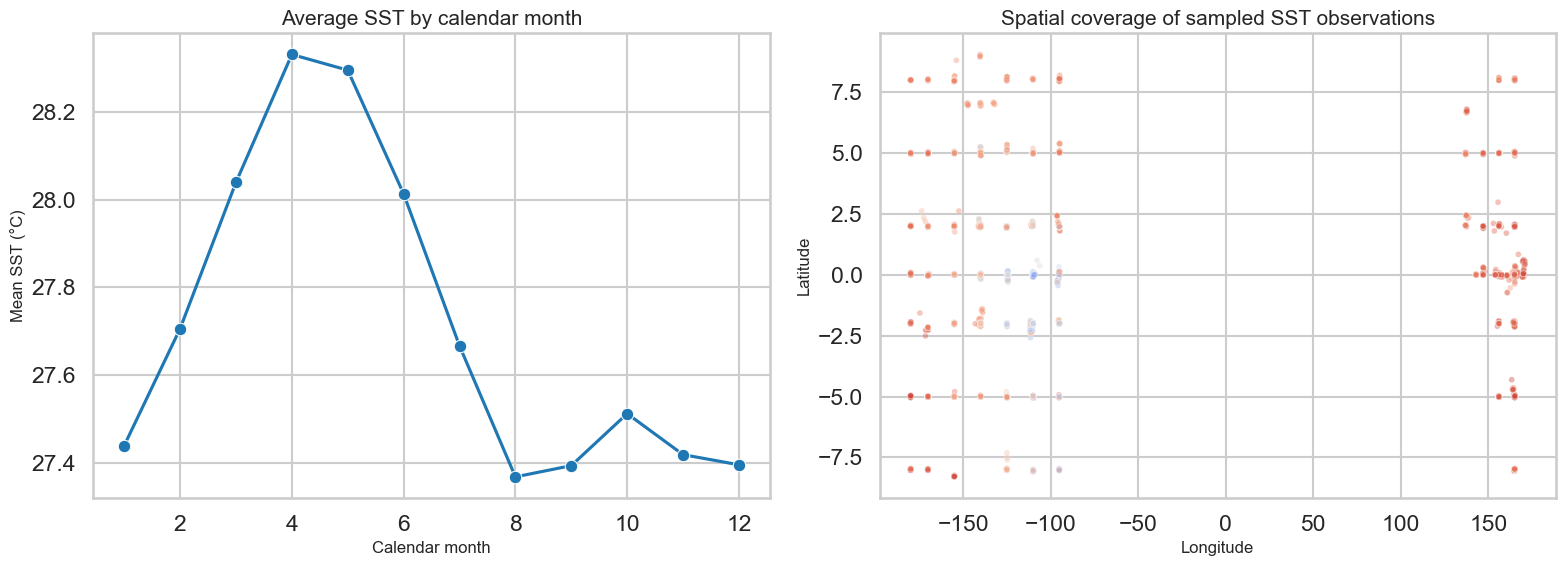

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=seasonal_profile, x="CalendarMonth", y="sst_mean", marker="o", ax=axes[0], color="tab:blue")
axes[0].set_title("Average SST by calendar month")
axes[0].set_xlabel("Calendar month")
axes[0].set_ylabel("Mean SST (°C)")

sns.scatterplot(
    data=df.dropna(subset=["Longitude", "Latitude", "Sea Surface Temp"]).sample(n=min(15000, df.dropna(subset=["Longitude", "Latitude", "Sea Surface Temp"]).shape[0]), random_state=RANDOM_STATE),
    x="Longitude",
    y="Latitude",
    hue="Sea Surface Temp",
    palette="coolwarm",
    alpha=0.4,
    s=18,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Spatial coverage of sampled SST observations")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## 7. Proxy rationale and benchmark construction

The dataset does not provide observation-level official El Niño labels. Therefore, the benchmark must be constructed indirectly. The proxy used here is deliberately conservative in its interpretation: it is **not** a replacement for NOAA ONI, but a consistent internal target for comparing unsupervised detectors.

The logic is as follows:
1. Estimate a climatological SST expectation for each location and calendar month.
2. Measure deviations from that local expectation.
3. Aggregate anomalies monthly and smooth them with a 3-month rolling mean.
4. Treat months above a threshold as proxy-positive.

This design is meant to reduce spatial sampling bias and emphasize persistent warm anomaly structure rather than isolated daily noise.


In [9]:
valid_obs = df.dropna(subset=["Date", "MonthStart", "Latitude", "Longitude", "Sea Surface Temp"]).copy()

climatology = (
    valid_obs.groupby(["Latitude", "Longitude", "CalendarMonth"])["Sea Surface Temp"]
    .mean()
    .rename("sst_location_climatology")
    .reset_index()
)

valid_obs = valid_obs.merge(
    climatology,
    on=["Latitude", "Longitude", "CalendarMonth"],
    how="left",
)
valid_obs["sst_local_anomaly"] = valid_obs["Sea Surface Temp"] - valid_obs["sst_location_climatology"]

monthly = (
    valid_obs.groupby("MonthStart")
    .agg(
        sst_mean=("Sea Surface Temp", "mean"),
        sst_std=("Sea Surface Temp", "std"),
        air_temp_mean=("Air Temp", "mean"),
        zonal_winds_mean=("Zonal Winds", "mean"),
        meridional_winds_mean=("Meridional Winds", "mean"),
        humidity_mean=("Humidity", "mean"),
        latitude_mean=("Latitude", "mean"),
        latitude_std=("Latitude", "std"),
        longitude_mean=("Longitude", "mean"),
        longitude_std=("Longitude", "std"),
        sst_local_anomaly_mean=("sst_local_anomaly", "mean"),
        sst_local_anomaly_std=("sst_local_anomaly", "std"),
        sample_count=("Observation", "count"),
    )
    .reset_index()
    .sort_values("MonthStart")
)

monthly["calendar_month"] = monthly["MonthStart"].dt.month
monthly["sst_anomaly_3mo"] = monthly["sst_local_anomaly_mean"].rolling(3, min_periods=3).mean()
monthly["proxy_el_nino"] = (monthly["sst_anomaly_3mo"] >= 0.10).astype(int)
monthly["month_sin"] = np.sin(2 * np.pi * monthly["calendar_month"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["calendar_month"] / 12)

proxy_rate = monthly["proxy_el_nino"].mean()
print(f"Monthly records: {len(monthly)}")
print(f"Proxy-positive months: {monthly['proxy_el_nino'].sum()} ({proxy_rate:.1%})")
monthly.head()


Monthly records: 208
Proxy-positive months: 21 (10.1%)


,MonthStart,sst_mean,sst_std,air_temp_mean,zonal_winds_mean,meridional_winds_mean,humidity_mean,latitude_mean,latitude_std,longitude_mean,longitude_std,sst_local_anomaly_mean,sst_local_anomaly_std,sample_count,calendar_month,sst_anomaly_3mo,proxy_el_nino,month_sin,month_cos
0,1980-03-01,25.244667,1.191649,25.866667,-3.633333,0.953333,NaN,-0.02,0.0,-109.46,0.0,-7.105427e-16,1.191649,15,3,NaN,0,1.000000,6.123234e-17
1,1980-08-01,22.201429,0.937690,21.878095,-4.319048,2.514286,NaN,0.00,0.0,-109.56,0.0,-6.767074e-16,0.937690,21,8,NaN,0,-0.866025,-5.000000e-01
2,1980-09-01,22.551333,0.854323,22.167000,-4.170000,3.263333,NaN,0.00,0.0,-109.56,0.0,1.184238e-15,0.854323,30,9,-6.767074e-17,0,-1.000000,-1.836970e-16
3,1980-10-01,21.286129,0.569150,21.278387,-3.954839,2.174194,NaN,0.00,0.0,-109.56,0.0,1.031433e-15,0.569150,31,10,5.129878e-16,0,-0.866025,5.000000e-01
4,1980-11-01,23.379000,0.894891,22.827333,-4.923333,4.150000,NaN,0.00,0.0,-109.56,0.0,-1.421085e-15,0.894891,30,11,2.648618e-16,0,-0.500000,8.660254e-01


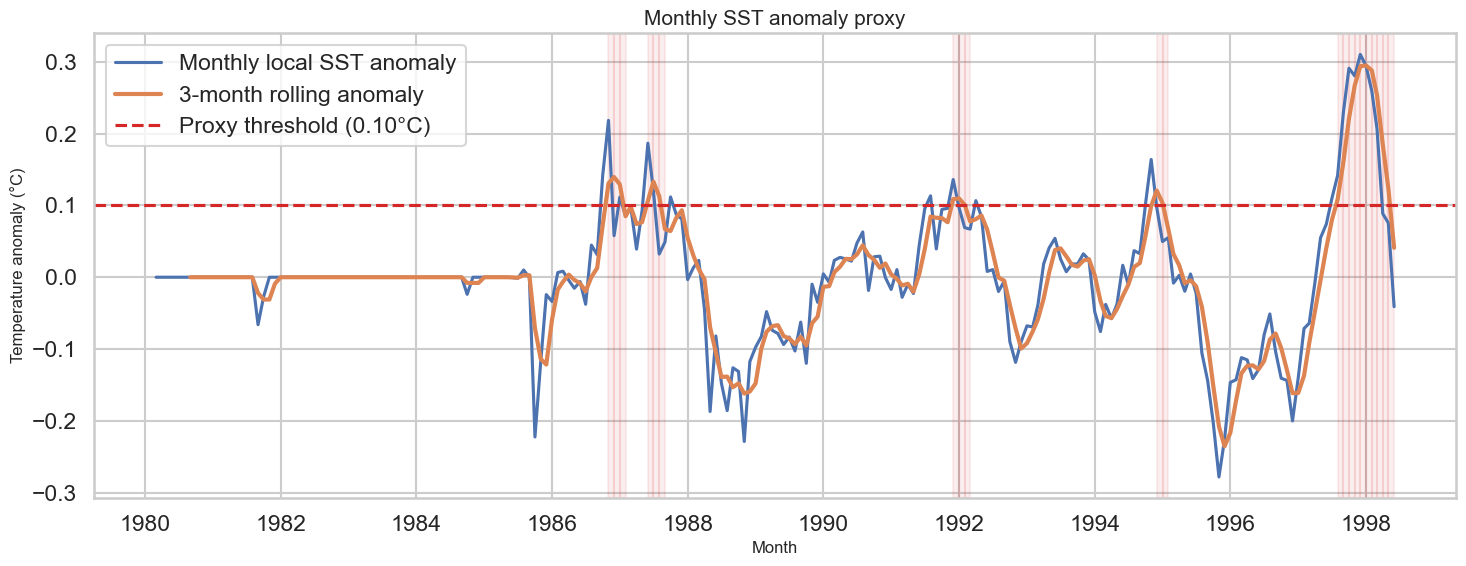

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=monthly, x="MonthStart", y="sst_local_anomaly_mean", label="Monthly local SST anomaly", ax=ax)
sns.lineplot(data=monthly, x="MonthStart", y="sst_anomaly_3mo", label="3-month rolling anomaly", linewidth=3, ax=ax)
ax.axhline(0.10, color="tab:red", linestyle="--", label="Proxy threshold (0.10°C)")
positive_months = monthly.loc[monthly["proxy_el_nino"] == 1, "MonthStart"]
for event_month in positive_months:
    ax.axvspan(event_month, event_month + pd.offsets.MonthBegin(1), color="tab:red", alpha=0.08)
ax.set_title("Monthly SST anomaly proxy")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 8. Proxy robustness diagnostics

Since the benchmark is internally constructed, it is important to show how sensitive proxy-positive frequency is to reasonable threshold changes. This does not create new ground truth; it simply shows whether the benchmark is extremely brittle or moderately stable.


In [11]:
threshold_grid = [0.05, 0.08, 0.10, 0.12, 0.15]
threshold_diagnostics = pd.DataFrame(
    {
        "threshold": threshold_grid,
        "positive_months": [(monthly["sst_anomaly_3mo"] >= t).sum() for t in threshold_grid],
    }
)
threshold_diagnostics["positive_rate"] = threshold_diagnostics["positive_months"] / len(monthly)
threshold_diagnostics.to_csv(OUTPUT_DIR / "proxy_threshold_diagnostics.csv", index=False)
threshold_diagnostics


,threshold,positive_months,positive_rate
0,0.05,43,0.206731
1,0.08,31,0.149038
2,0.10,21,0.100962
3,0.12,14,0.067308
4,0.15,8,0.038462


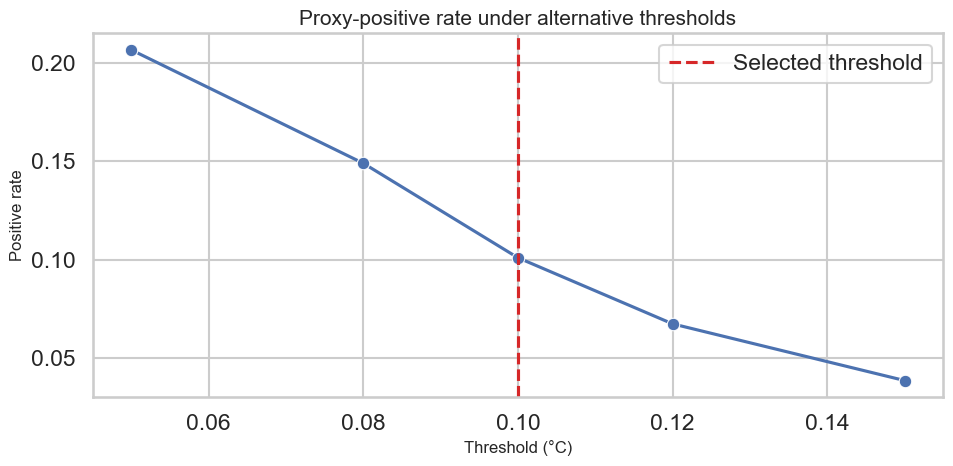

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=threshold_diagnostics, x="threshold", y="positive_rate", marker="o", ax=ax)
ax.axvline(0.10, color="tab:red", linestyle="--", label="Selected threshold")
ax.set_title("Proxy-positive rate under alternative thresholds")
ax.set_xlabel("Threshold (°C)")
ax.set_ylabel("Positive rate")
ax.legend()
plt.tight_layout()
plt.show()


The threshold diagnostic shows that the chosen benchmark is not the only plausible internal definition. However, the selected `0.10°C` threshold keeps the positive class relatively sparse while preserving a usable number of positive months for model comparison. This supports its use as a comparative benchmark rather than as an operational claim.


## 9. Monthly feature engineering and diagnostics

Two feature spaces are retained. The SST-only representation keeps the benchmark close to the core climate signal, while the multivariate representation tests whether added atmospheric context improves proxy alignment. A feature-diagnostic stage is included here because failure of multivariate features can itself be analytically informative.


In [13]:
sst_only_features = [
    "sst_mean",
    "sst_std",
    "sst_local_anomaly_mean",
    "sst_local_anomaly_std",
    "month_sin",
    "month_cos",
]

multivariate_features = sst_only_features + [
    "air_temp_mean",
    "zonal_winds_mean",
    "meridional_winds_mean",
    "humidity_mean",
    "latitude_mean",
    "latitude_std",
    "longitude_mean",
    "longitude_std",
    "sample_count",
]

monthly_features = monthly[sst_only_features + [f for f in multivariate_features if f not in sst_only_features]].copy()
feature_corr = monthly_features.corr(numeric_only=True)

X_sst = monthly[sst_only_features].copy()
X_multi = monthly[multivariate_features].copy()
y_proxy = monthly["proxy_el_nino"].astype(int).to_numpy()

print("SST-only features:", sst_only_features)
print("Multivariate features:", multivariate_features)


SST-only features: ['sst_mean', 'sst_std', 'sst_local_anomaly_mean', 'sst_local_anomaly_std', 'month_sin', 'month_cos']
Multivariate features: ['sst_mean', 'sst_std', 'sst_local_anomaly_mean', 'sst_local_anomaly_std', 'month_sin', 'month_cos', 'air_temp_mean', 'zonal_winds_mean', 'meridional_winds_mean', 'humidity_mean', 'latitude_mean', 'latitude_std', 'longitude_mean', 'longitude_std', 'sample_count']


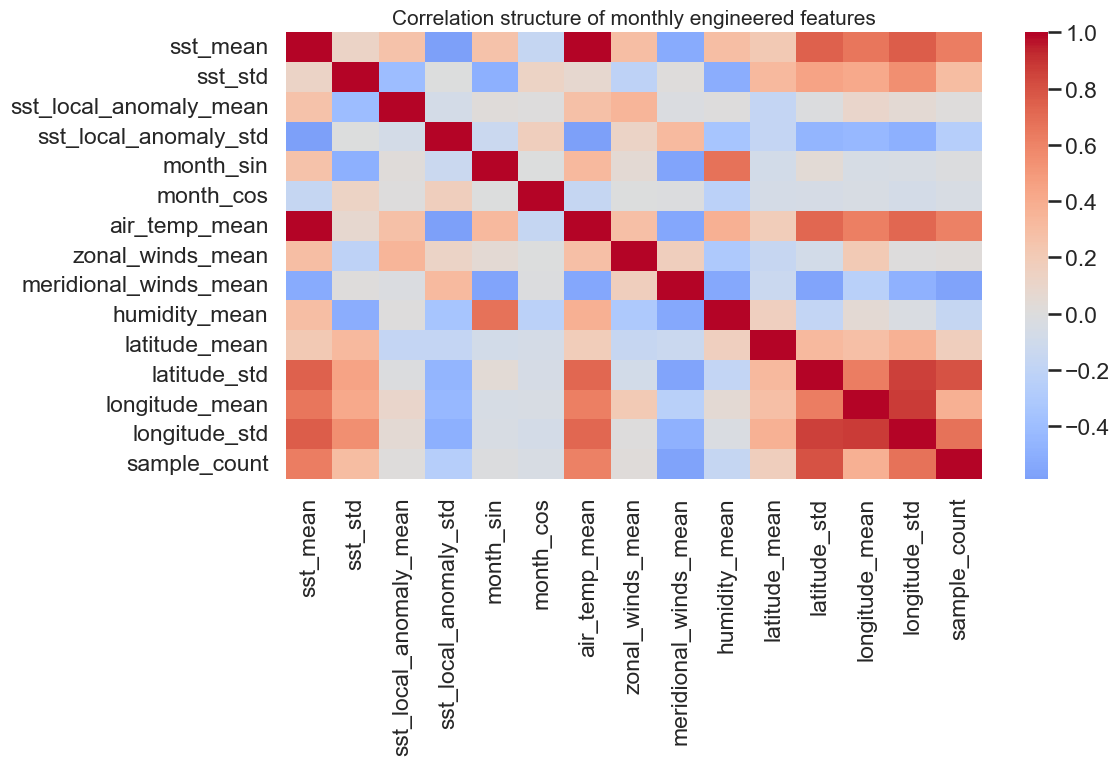

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(feature_corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation structure of monthly engineered features")
plt.tight_layout()
plt.show()


The correlation structure is useful analytically because it shows whether multivariate features may be adding genuinely new information or mostly re-encoding SST-related variation. If extra features are highly redundant or noisy under monthly aggregation, weaker multivariate benchmark performance becomes easier to interpret.


## 10. Benchmark models and evaluation logic

The benchmark intentionally remains compact. Rather than introducing many additional models, the notebook deepens validity through common preprocessing, careful metric interpretation, and several post hoc diagnostics. This keeps the study focused on whether `IsolationForest` is competitive under a consistent monthly proxy benchmark.


In [15]:
def evaluate_predictions(y_true, y_pred, scores):
    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, scores),
    }
    metrics["roc_auc"] = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    return metrics

def fit_iforest(X, contamination=DEFAULT_CONTAMINATION, n_estimators=300):
    pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=RANDOM_STATE)),
        ]
    )
    pipeline.fit(X)
    scores = -pipeline.decision_function(X)
    preds = (pipeline.predict(X) == -1).astype(int)
    return pipeline, preds, scores

def fit_ocsvm(X):
    pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=DEFAULT_CONTAMINATION)),
        ]
    )
    pipeline.fit(X)
    scores = -pipeline.decision_function(X)
    preds = (pipeline.predict(X) == -1).astype(int)
    return pipeline, preds, scores

def fit_lof(X):
    pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LocalOutlierFactor(n_neighbors=20, contamination=DEFAULT_CONTAMINATION, novelty=True)),
        ]
    )
    pipeline.fit(X)
    scores = -pipeline.decision_function(X)
    preds = (pipeline.predict(X) == -1).astype(int)
    return pipeline, preds, scores

def run_benchmark(feature_name, X, y_true):
    results = []
    prediction_frame = monthly[["MonthStart", "proxy_el_nino", "sst_local_anomaly_mean", "sst_anomaly_3mo"]].copy()
    trainers = {
        "IsolationForest": fit_iforest,
        "OneClassSVM": fit_ocsvm,
        "LocalOutlierFactor": fit_lof,
    }
    for model_name, trainer in trainers.items():
        _, preds, scores = trainer(X)
        metrics = evaluate_predictions(y_true, preds, scores)
        metrics.update({"feature_set": feature_name, "model": model_name, "predicted_anomaly_rate": preds.mean()})
        results.append(metrics)
        prediction_frame[f"{feature_name}_{model_name}_pred"] = preds
        prediction_frame[f"{feature_name}_{model_name}_score"] = scores
    return pd.DataFrame(results), prediction_frame

benchmark_sst, predictions_sst = run_benchmark("sst_only", X_sst, y_proxy)
benchmark_multi, predictions_multi = run_benchmark("multivariate", X_multi, y_proxy)
benchmark_table = (
    pd.concat([benchmark_sst, benchmark_multi], ignore_index=True)
    .sort_values(["f1", "average_precision"], ascending=False)
    .reset_index(drop=True)
)
benchmark_table


,precision,recall,f1,balanced_accuracy,average_precision,roc_auc,feature_set,model,predicted_anomaly_rate
0,0.444444,0.380952,0.410256,0.663738,0.350681,0.749936,sst_only,LocalOutlierFactor,0.086538
1,0.315789,0.285714,0.300000,0.608098,0.261500,0.756812,multivariate,LocalOutlierFactor,0.091346
2,0.285714,0.285714,0.285714,0.602750,0.185854,0.654953,sst_only,IsolationForest,0.100962
3,0.285714,0.285714,0.285714,0.602750,0.173416,0.633817,multivariate,IsolationForest,0.100962
4,0.208333,0.238095,0.222222,0.568245,0.150553,0.552839,sst_only,OneClassSVM,0.115385
5,0.173913,0.190476,0.181818,0.544436,0.161592,0.600713,multivariate,OneClassSVM,0.110577


In [16]:
prediction_table = predictions_sst.merge(
    predictions_multi.drop(columns=["proxy_el_nino", "sst_local_anomaly_mean", "sst_anomaly_3mo"]),
    on="MonthStart",
    how="left",
)
benchmark_table.to_csv(OUTPUT_DIR / "benchmark_metrics.csv", index=False)
prediction_table.to_csv(OUTPUT_DIR / "monthly_predictions.csv", index=False)
display(benchmark_table)


,precision,recall,f1,balanced_accuracy,average_precision,roc_auc,feature_set,model,predicted_anomaly_rate
0,0.444444,0.380952,0.410256,0.663738,0.350681,0.749936,sst_only,LocalOutlierFactor,0.086538
1,0.315789,0.285714,0.300000,0.608098,0.261500,0.756812,multivariate,LocalOutlierFactor,0.091346
2,0.285714,0.285714,0.285714,0.602750,0.185854,0.654953,sst_only,IsolationForest,0.100962
3,0.285714,0.285714,0.285714,0.602750,0.173416,0.633817,multivariate,IsolationForest,0.100962
4,0.208333,0.238095,0.222222,0.568245,0.150553,0.552839,sst_only,OneClassSVM,0.115385
5,0.173913,0.190476,0.181818,0.544436,0.161592,0.600713,multivariate,OneClassSVM,0.110577


## 11. Main benchmark interpretation

The main comparison asks two questions: whether `IsolationForest` is competitive with common unsupervised baselines, and whether additional atmospheric features improve benchmark alignment. The answer is mixed. `IsolationForest` remains viable, but the strongest benchmark alignment is currently achieved by `LocalOutlierFactor` with the SST-only feature set.


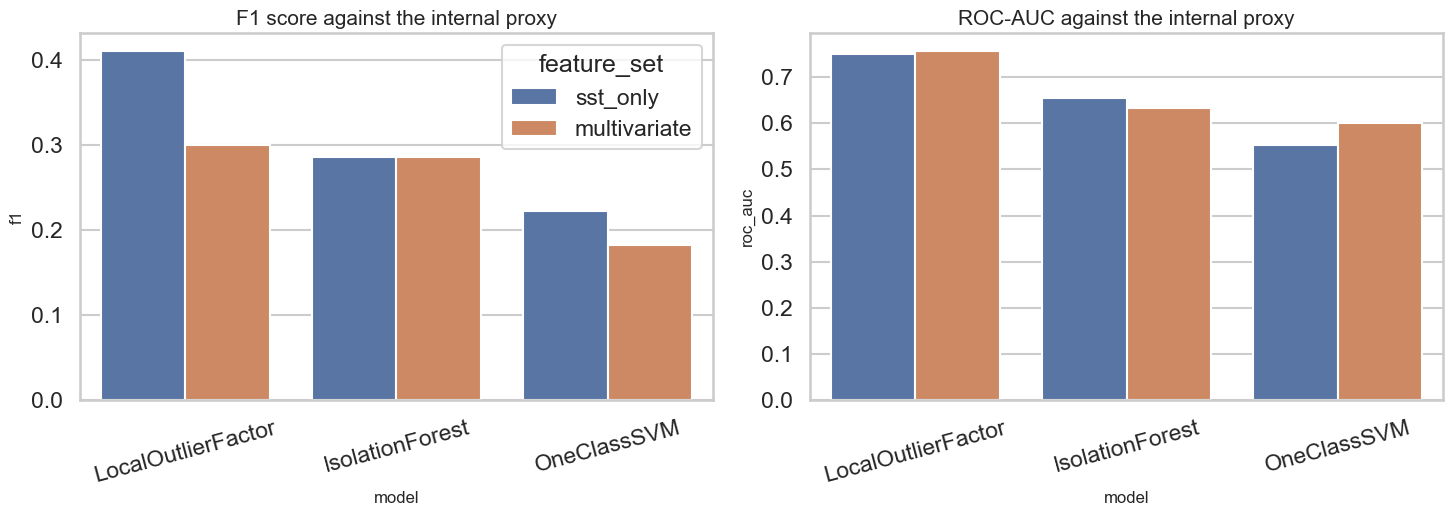

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(data=benchmark_table, x="model", y="f1", hue="feature_set", ax=axes[0])
axes[0].set_title("F1 score against the internal proxy")
axes[0].tick_params(axis="x", rotation=15)
sns.barplot(data=benchmark_table, x="model", y="roc_auc", hue="feature_set", ax=axes[1])
axes[1].set_title("ROC-AUC against the internal proxy")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend_.remove()
plt.tight_layout()
plt.show()


In [18]:
feature_comparison = benchmark_table.pivot(index="model", columns="feature_set", values="f1")
feature_comparison["delta_multivariate_minus_sst"] = feature_comparison["multivariate"] - feature_comparison["sst_only"]
feature_comparison.to_csv(OUTPUT_DIR / "feature_set_comparison.csv")
feature_comparison


feature_set,multivariate,sst_only,delta_multivariate_minus_sst
model,,,
IsolationForest,0.285714,0.285714,0.000000
LocalOutlierFactor,0.300000,0.410256,-0.110256
OneClassSVM,0.181818,0.222222,-0.040404


The feature-set comparison is analytically important. A stronger multivariate result would suggest that monthly atmospheric context adds useful anomaly information beyond SST. Here, however, the multivariate setting does not outperform SST-only features, implying that the present proxy is more directly aligned with SST-centered structure than with broader aggregated meteorological context.


## 12. Isolation Forest robustness and sensitivity

Because `IsolationForest` is the focal model, it deserves deeper inspection beyond one benchmark row. The sensitivity sweep below evaluates whether the model's benchmark alignment is stable under reasonable contamination and tree-count settings.


In [19]:
def evaluate_iforest_sensitivity(X, y_true, contamination_values=(0.05, 0.10, 0.15), estimator_values=(100, 300, 500)):
    rows = []
    base_imputer = SimpleImputer(strategy="median")
    base_scaler = StandardScaler()
    X_ready = base_imputer.fit_transform(X)
    X_ready = base_scaler.fit_transform(X_ready)
    for contamination in contamination_values:
        for n_estimators in estimator_values:
            model = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=RANDOM_STATE)
            model.fit(X_ready)
            scores = -model.decision_function(X_ready)
            preds = (model.predict(X_ready) == -1).astype(int)
            metrics = evaluate_predictions(y_true, preds, scores)
            metrics.update({
                "contamination": contamination,
                "n_estimators": n_estimators,
                "predicted_anomaly_rate": preds.mean(),
            })
            rows.append(metrics)
    return pd.DataFrame(rows)

sensitivity_table = evaluate_iforest_sensitivity(X_multi, y_proxy)
sensitivity_table.to_csv(OUTPUT_DIR / "iforest_sensitivity.csv", index=False)
sensitivity_table.sort_values(["f1", "average_precision"], ascending=False)


,precision,recall,f1,balanced_accuracy,average_precision,roc_auc,contamination,n_estimators,predicted_anomaly_rate
5,0.285714,0.285714,0.285714,0.602750,0.180961,0.658518,0.10,500,0.100962
4,0.285714,0.285714,0.285714,0.602750,0.173416,0.633817,0.10,300,0.100962
8,0.218750,0.333333,0.264151,0.599822,0.180961,0.658518,0.15,500,0.153846
7,0.218750,0.333333,0.264151,0.599822,0.173416,0.633817,0.15,300,0.153846
3,0.190476,0.190476,0.190476,0.549784,0.152614,0.612172,0.10,100,0.100962
6,0.156250,0.238095,0.188679,0.546855,0.152614,0.612172,0.15,100,0.153846
2,0.181818,0.095238,0.125000,0.523555,0.180961,0.658518,0.05,500,0.052885
1,0.090909,0.047619,0.062500,0.497072,0.173416,0.633817,0.05,300,0.052885
0,0.000000,0.000000,0.000000,0.470588,0.152614,0.612172,0.05,100,0.052885


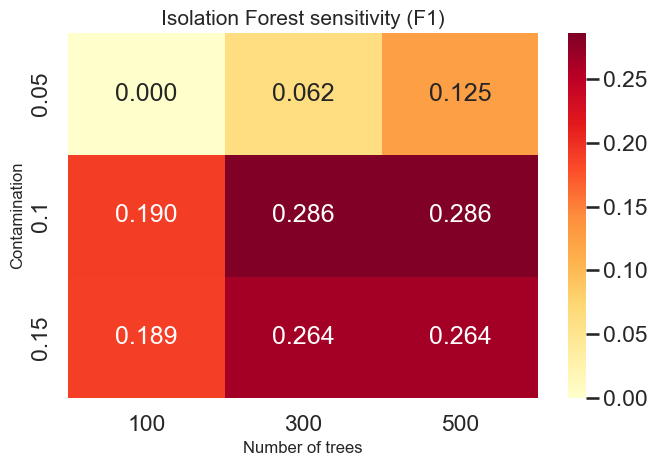

In [20]:
sensitivity_pivot = sensitivity_table.pivot(index="contamination", columns="n_estimators", values="f1")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(sensitivity_pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
ax.set_title("Isolation Forest sensitivity (F1)")
ax.set_xlabel("Number of trees")
ax.set_ylabel("Contamination")
plt.tight_layout()
plt.show()


The sensitivity analysis shows that `IsolationForest` is responsive to contamination assumptions in a meaningful way. Low contamination under-detects anomalies, while higher contamination improves recall but does not lift the model above `LocalOutlierFactor` on the current proxy benchmark. This supports a nuanced interpretation: `IsolationForest` is viable and tunable, but not dominant under the current experimental assumptions.


## 13. Score distributions and model agreement

A benchmark table alone cannot explain *why* models differ. The next diagnostics examine how anomaly scores are distributed and how often models agree or disagree on the same months.


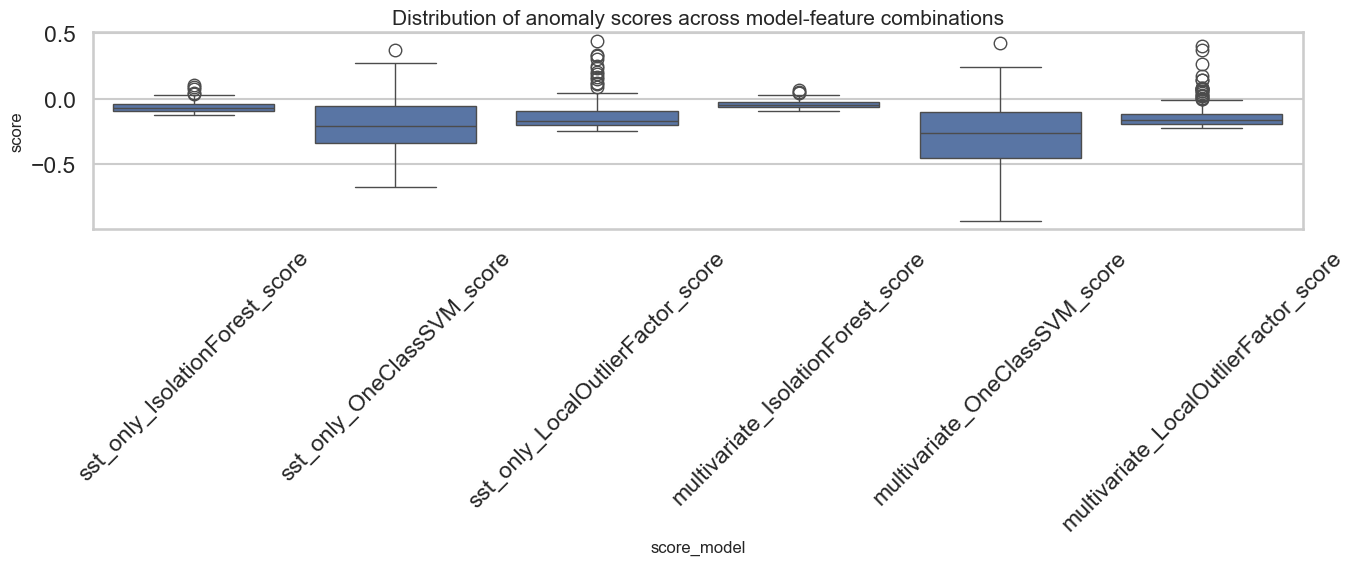

In [21]:
score_columns = [col for col in prediction_table.columns if col.endswith("_score")]
pred_columns = [col for col in prediction_table.columns if col.endswith("_pred")]

score_long = prediction_table.melt(
    id_vars=["MonthStart", "proxy_el_nino"],
    value_vars=score_columns,
    var_name="score_model",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=score_long, x="score_model", y="score", ax=ax)
ax.set_title("Distribution of anomaly scores across model-feature combinations")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [22]:
agreement_frame = prediction_table[["MonthStart", "proxy_el_nino"] + pred_columns].copy()
agreement_frame["total_flags"] = agreement_frame[pred_columns].sum(axis=1)
agreement_frame["all_models_agree"] = (agreement_frame["total_flags"].isin([0, len(pred_columns)])).astype(int)
agreement_summary = pd.DataFrame(
    {
        "months_with_any_flag": [int((agreement_frame["total_flags"] > 0).sum())],
        "months_with_three_or_more_flags": [int((agreement_frame["total_flags"] >= 3).sum())],
        "months_with_full_agreement": [int(agreement_frame["all_models_agree"].sum())],
    }
)
agreement_frame.to_csv(OUTPUT_DIR / "model_agreement_by_month.csv", index=False)
agreement_summary


,months_with_any_flag,months_with_three_or_more_flags,months_with_full_agreement
0,55,19,157


Agreement analysis is helpful because it separates two cases: months that many detectors consider unusual, and months that are highly model-dependent. Strong disagreement can suggest that the anomaly structure is sensitive to model assumptions rather than being universally salient.


## 14. Event-focused interpretation

Since the notebook is motivated by climate-event indication rather than generic outlier detection, it is useful to inspect the months with the strongest proxy values and compare them to detector responses.


In [23]:
top_proxy_months = monthly.nlargest(12, "sst_anomaly_3mo")[["MonthStart", "sst_anomaly_3mo", "proxy_el_nino"]]
top_proxy_months = top_proxy_months.merge(
    prediction_table[["MonthStart"] + pred_columns],
    on="MonthStart",
    how="left",
).sort_values("MonthStart")
top_proxy_months.to_csv(OUTPUT_DIR / "top_proxy_months.csv", index=False)
top_proxy_months


,MonthStart,sst_anomaly_3mo,proxy_el_nino,sst_only_IsolationForest_pred,sst_only_OneClassSVM_pred,sst_only_LocalOutlierFactor_pred,multivariate_IsolationForest_pred,multivariate_OneClassSVM_pred,multivariate_LocalOutlierFactor_pred
10,1986-11-01,0.130674,1,0,1,0,0,0,0
8,1986-12-01,0.139502,1,0,0,0,0,0,0
11,1987-01-01,0.129231,1,0,0,0,0,0,0
9,1987-07-01,0.133042,1,0,0,0,0,0,0
7,1997-09-01,0.160404,1,1,0,1,1,1,1
5,1997-10-01,0.220819,1,1,1,1,1,1,1
3,1997-11-01,0.266924,1,1,0,1,0,0,1
1,1997-12-01,0.293724,1,1,0,1,1,0,1
0,1998-01-01,0.294802,1,1,1,1,1,1,1
2,1998-02-01,0.287789,1,1,1,1,1,0,1


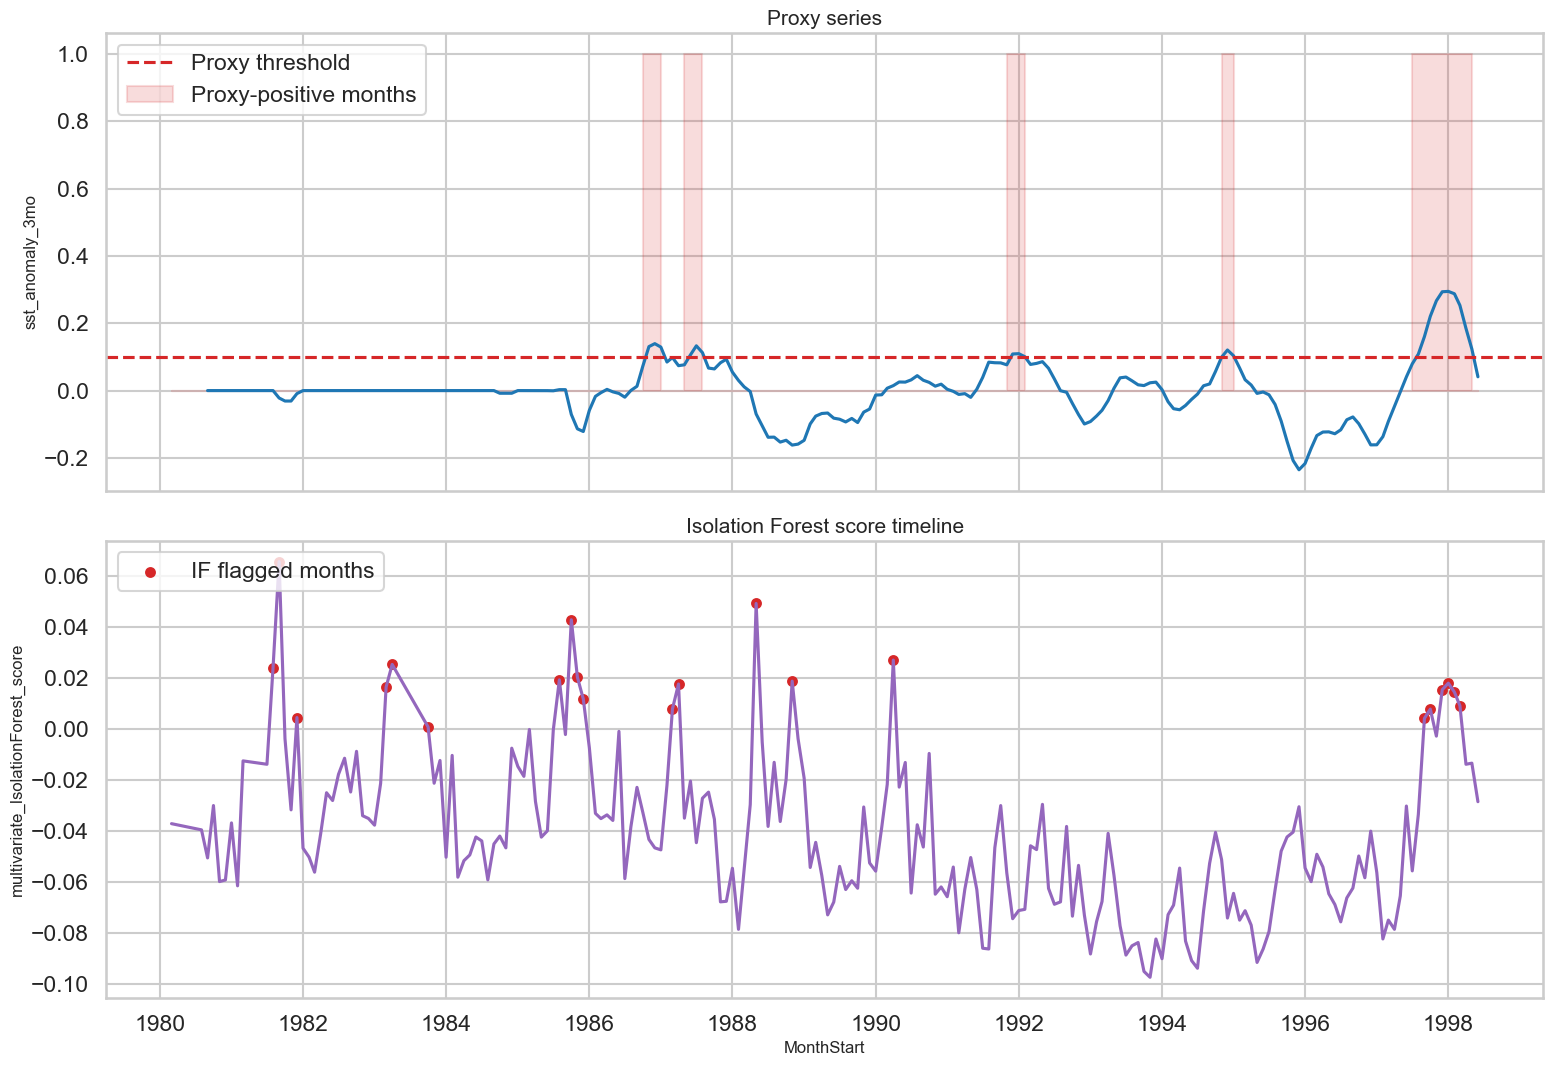

In [24]:
main_model_pred = prediction_table["multivariate_IsolationForest_pred"]
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
sns.lineplot(data=prediction_table, x="MonthStart", y="sst_anomaly_3mo", ax=axes[0], color="tab:blue")
axes[0].axhline(0.10, color="tab:red", linestyle="--", label="Proxy threshold")
axes[0].fill_between(prediction_table["MonthStart"], 0, prediction_table["proxy_el_nino"], color="tab:red", alpha=0.16, step="pre", label="Proxy-positive months")
axes[0].set_title("Proxy series")
axes[0].legend(loc="upper left")

sns.lineplot(data=prediction_table, x="MonthStart", y="multivariate_IsolationForest_score", ax=axes[1], color="tab:purple")
axes[1].scatter(
    prediction_table.loc[main_model_pred == 1, "MonthStart"],
    prediction_table.loc[main_model_pred == 1, "multivariate_IsolationForest_score"],
    color="tab:red",
    s=40,
    label="IF flagged months",
)
axes[1].set_title("Isolation Forest score timeline")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()


In [25]:
analysis_frame = prediction_table[["MonthStart", "proxy_el_nino", "multivariate_IsolationForest_pred", "multivariate_IsolationForest_score"]].copy()
analysis_frame["if_case"] = np.select(
    [
        (analysis_frame["proxy_el_nino"] == 1) & (analysis_frame["multivariate_IsolationForest_pred"] == 1),
        (analysis_frame["proxy_el_nino"] == 1) & (analysis_frame["multivariate_IsolationForest_pred"] == 0),
        (analysis_frame["proxy_el_nino"] == 0) & (analysis_frame["multivariate_IsolationForest_pred"] == 1),
    ],
    ["true_positive_proxy", "false_negative_proxy", "false_positive_proxy"],
    default="true_negative_proxy",
)
case_summary = analysis_frame["if_case"].value_counts().rename_axis("case").reset_index(name="months")
case_summary.to_csv(OUTPUT_DIR / "iforest_case_summary.csv", index=False)
case_summary


,case,months
0,true_negative_proxy,172
1,false_positive_proxy,15
2,false_negative_proxy,15
3,true_positive_proxy,6


This case-based summary helps interpret the role of `IsolationForest`. False negatives indicate months that the internal proxy treats as warm-event-like but iForest does not isolate strongly, while false positives indicate months that the model treats as structurally unusual even when the proxy does not. These two error types should be interpreted differently in climate settings.


## 15. Spatial context during proxy-positive periods

The next figure adds spatial context by contrasting the broader observation cloud with months classified as proxy-positive. This does not establish event causality, but it helps illustrate whether the benchmarked periods correspond to visibly warm SST structure across the sampled observation space.


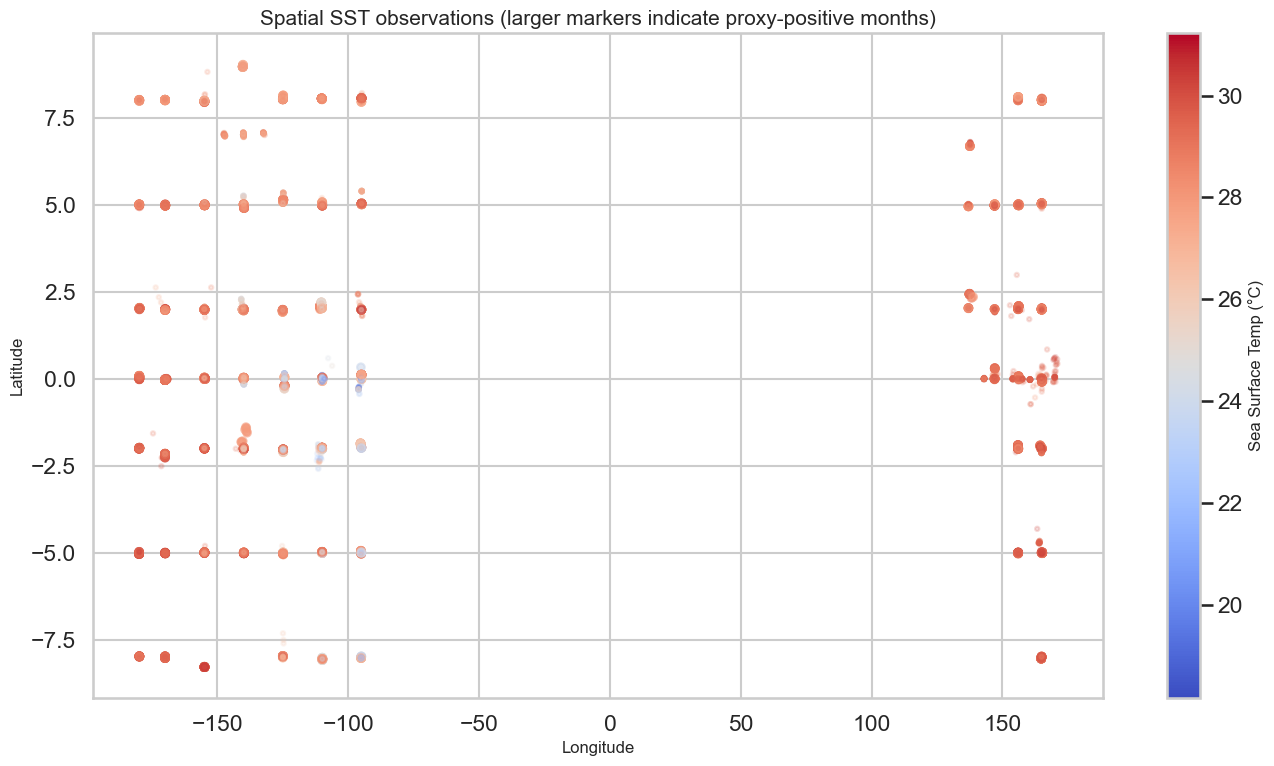

In [26]:
positive_months_set = set(monthly.loc[monthly["proxy_el_nino"] == 1, "MonthStart"])
spatial_sample = valid_obs.copy()
spatial_sample["proxy_el_nino"] = spatial_sample["MonthStart"].isin(positive_months_set).astype(int)
spatial_sample = spatial_sample.dropna(subset=["Latitude", "Longitude", "Sea Surface Temp"])
spatial_sample = spatial_sample.sample(n=min(15000, len(spatial_sample)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    spatial_sample["Longitude"],
    spatial_sample["Latitude"],
    c=spatial_sample["Sea Surface Temp"],
    cmap="coolwarm",
    s=np.where(spatial_sample["proxy_el_nino"] == 1, 30, 10),
    alpha=np.where(spatial_sample["proxy_el_nino"] == 1, 0.60, 0.18),
)
ax.set_title("Spatial SST observations (larger markers indicate proxy-positive months)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax, label="Sea Surface Temp (°C)")
plt.tight_layout()
plt.show()


## 16. Final findings and validity statement

This notebook supports the following conclusions:

1. The monthly SST anomaly proxy is analytically grounded, but remains an internal benchmark rather than external truth.
2. `LocalOutlierFactor` with the `sst_only` feature set shows the strongest alignment with the current proxy benchmark.
3. `IsolationForest` remains a valid focal method because it is scalable, tunable, and analytically interpretable under sensitivity analysis, even though it does not dominate the benchmark.
4. The weaker multivariate results suggest that monthly atmospheric aggregation does not automatically improve anomaly alignment and may introduce noise relative to SST-centered representations.


In [27]:
best_row = benchmark_table.sort_values(["f1", "average_precision"], ascending=False).iloc[0]
reproducibility_manifest = pd.DataFrame(
    {
        "artifact": [
            "benchmark_metrics.csv",
            "monthly_predictions.csv",
            "iforest_sensitivity.csv",
            "proxy_threshold_diagnostics.csv",
            "feature_set_comparison.csv",
            "model_agreement_by_month.csv",
            "top_proxy_months.csv",
            "iforest_case_summary.csv",
            "data_missingness_summary.csv",
        ]
    }
)
display(best_row)
display(reproducibility_manifest)


precision                           0.444444
recall                              0.380952
f1                                  0.410256
balanced_accuracy                   0.663738
average_precision                   0.350681
roc_auc                             0.749936
feature_set                         sst_only
model                     LocalOutlierFactor
predicted_anomaly_rate              0.086538
Name: 0, dtype: object

,artifact
0,benchmark_metrics.csv
1,monthly_predictions.csv
2,iforest_sensitivity.csv
3,proxy_threshold_diagnostics.csv
4,feature_set_comparison.csv
5,model_agreement_by_month.csv
6,top_proxy_months.csv
7,iforest_case_summary.csv
8,data_missingness_summary.csv


## 17. Conclusion

This notebook provides a comprehensive analytical supplement to the paper by combining literature-backed motivation, deeper data diagnostics, proxy robustness analysis, benchmark comparison, and event-level interpretation. The central result remains unchanged: the strongest alignment with the internal proxy is achieved by `LocalOutlierFactor` on `sst_only` features, while `IsolationForest` remains competitive but not dominant.

The main methodological limitation also remains unchanged. Because the benchmark depends on a dataset-internal SST anomaly proxy rather than official ENSO event labels, the reported metrics should be interpreted as comparative evidence under constrained labeling conditions, not as final operational validation against externally verified El Niño ground truth.
